# 2. Análisis exploratorio de datos (EDA)

En este notebook exploraremos los datos limpios para identificar patrones y relaciones asociados con la supervivencia de los pasajeros.

## Importar paquetes

In [1]:
%matplotlib inline
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Cargar los datos limpios

In [2]:
df = pd.read_csv('./data/titanic_clean.csv')
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


## Glosario

El **análisis exploratorio de datos (EDA)** es el proceso de examinar y visualizar datos para resumir sus principales características mediante técnicas estadísticas y gráficas. Su objetivo es comprender distribuciones y relaciones, detectar posibles anomalías e identificar patrones e hipótesis antes de aplicar modelos predictivos.

## Análisis

Comenzamos observando una muestra aleatoria de cuatro registros.

In [3]:
df.sample(4)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
405,0,2,male,34.0,1,0,21.00,S
604,1,1,male,35.0,0,0,26.55,C
460,1,1,male,48.0,0,0,26.55,S
134,0,2,male,25.0,0,0,13.00,S


### `Survived`

La variable objetivo indica si el pasajero falleció (`0`) o sobrevivió (`1`).

In [4]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

El conjunto de entrenamiento contiene 549 pasajeros que fallecieron y 342 que sobrevivieron. Visualizamos estos conteos mediante una gráfica de barras.

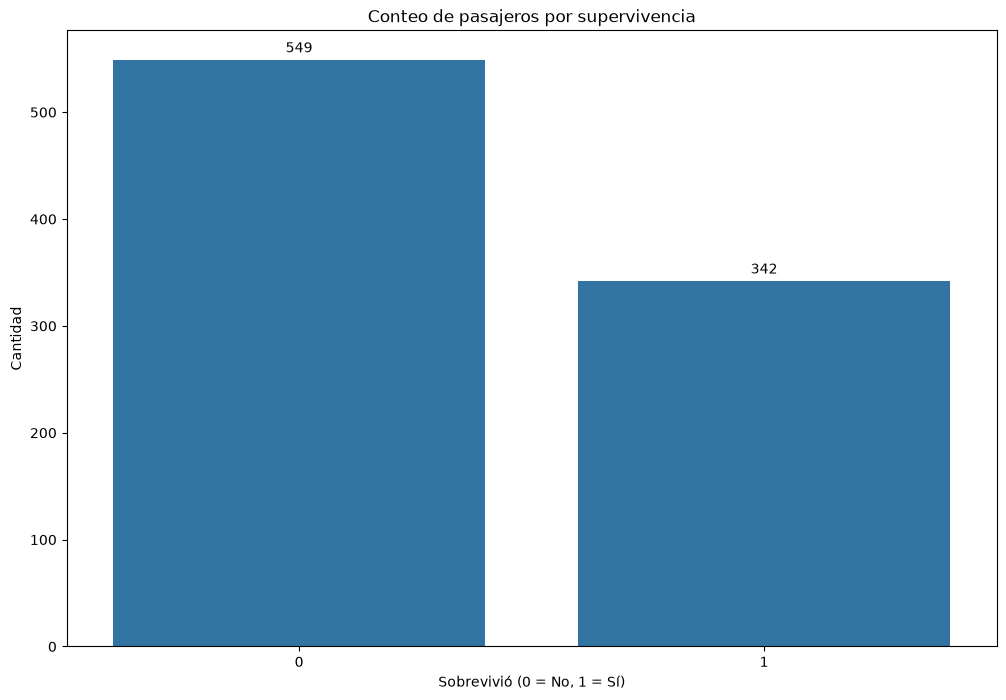

In [5]:
plt.figure(figsize=(12, 8))

survived_counts = df['Survived'].value_counts().sort_index()
ax = sns.barplot(x=survived_counts.index, y=survived_counts.values)
ax.bar_label(ax.containers[0], padding=3)

plt.title('Conteo de pasajeros por supervivencia')
plt.xlabel('Sobrevivió (0 = No, 1 = Sí)')
plt.ylabel('Cantidad')
plt.show()

### `Survived` y `Pclass`

Comparamos la cantidad de pasajeros que sobrevivieron y fallecieron dentro de cada una de las tres clases.

In [6]:
pd.crosstab(df['Pclass'], df['Survived'], margins=True)

Survived,0,1,All
Pclass,,,
1,80,136,216
2,97,87,184
3,372,119,491
All,549,342,891


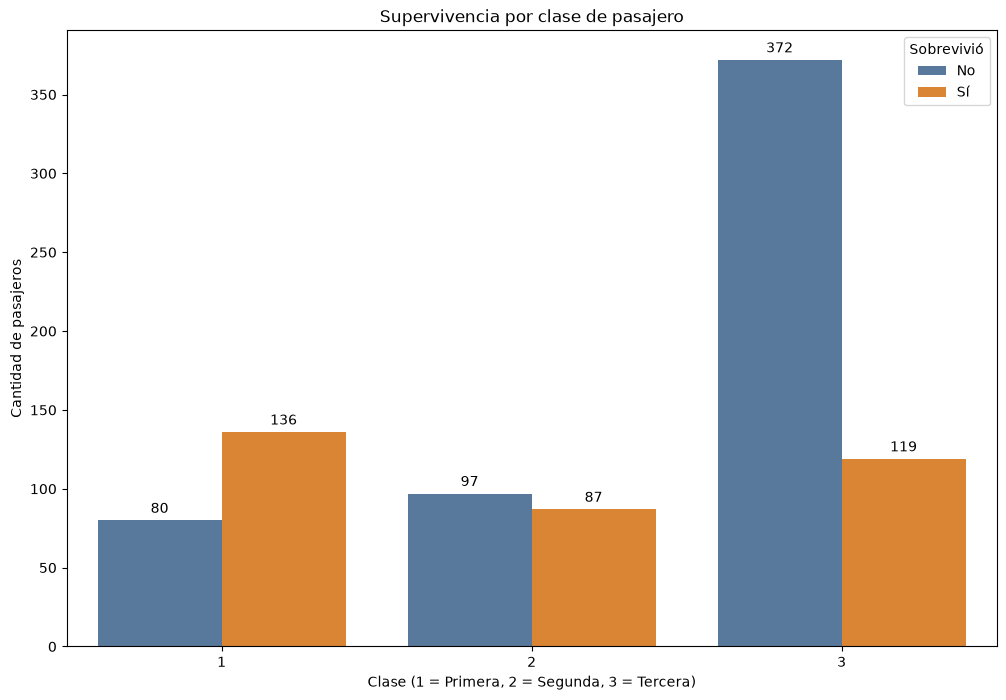

In [7]:
plt.figure(figsize=(12, 8))

ax = sns.countplot(
    data=df,
    x='Pclass',
    hue='Survived',
    palette={0: '#4C78A8', 1: '#F58518'}
)

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title('Supervivencia por clase de pasajero')
plt.xlabel('Clase (1 = Primera, 2 = Segunda, 3 = Tercera)')
plt.ylabel('Cantidad de pasajeros')
plt.legend(title='Sobrevivió', labels=['No', 'Sí'])
plt.show()

### `Survived` y `Sex`

Comparamos la cantidad de pasajeros que sobrevivieron y fallecieron según su sexo.

In [8]:
pd.crosstab(df['Sex'], df['Survived'], margins=True)

Survived,0,1,All
Sex,,,
female,81,233,314
male,468,109,577
All,549,342,891


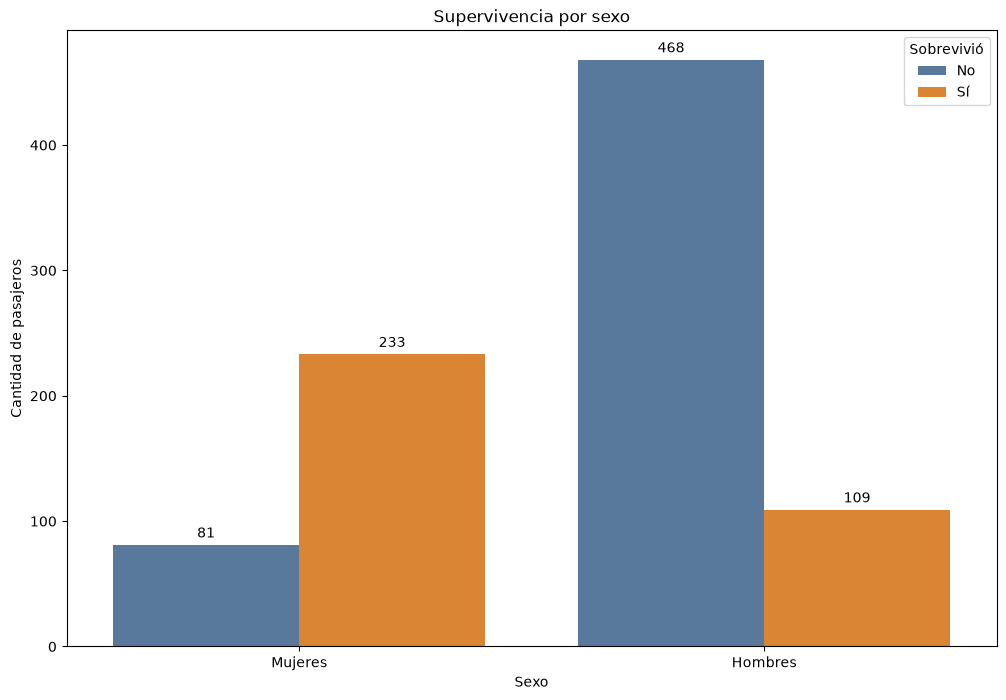

In [9]:
plt.figure(figsize=(12, 8))

ax = sns.countplot(
    data=df,
    x='Sex',
    hue='Survived',
    order=['female', 'male'],
    palette={0: '#4C78A8', 1: '#F58518'}
)

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title('Supervivencia por sexo')
plt.xlabel('Sexo')
plt.ylabel('Cantidad de pasajeros')
plt.xticks([0, 1], ['Mujeres', 'Hombres'])
plt.legend(title='Sobrevivió', labels=['No', 'Sí'])
plt.show()

### `Survived` y `Embarked`

Analizamos la supervivencia según el puerto de embarque: Cherbourg (`C`), Queenstown (`Q`) y Southampton (`S`).

In [10]:
pd.crosstab(df['Embarked'], df['Survived'], margins=True)

Survived,0,1,All
Embarked,,,
C,75,93,168
Q,47,30,77
S,427,219,646
All,549,342,891


In [11]:
(df.groupby('Embarked')['Survived'].mean() * 100).round(2).rename('Tasa de supervivencia (%)')

Embarked
C    55.36
Q    38.96
S    33.90
Name: Tasa de supervivencia (%), dtype: float64

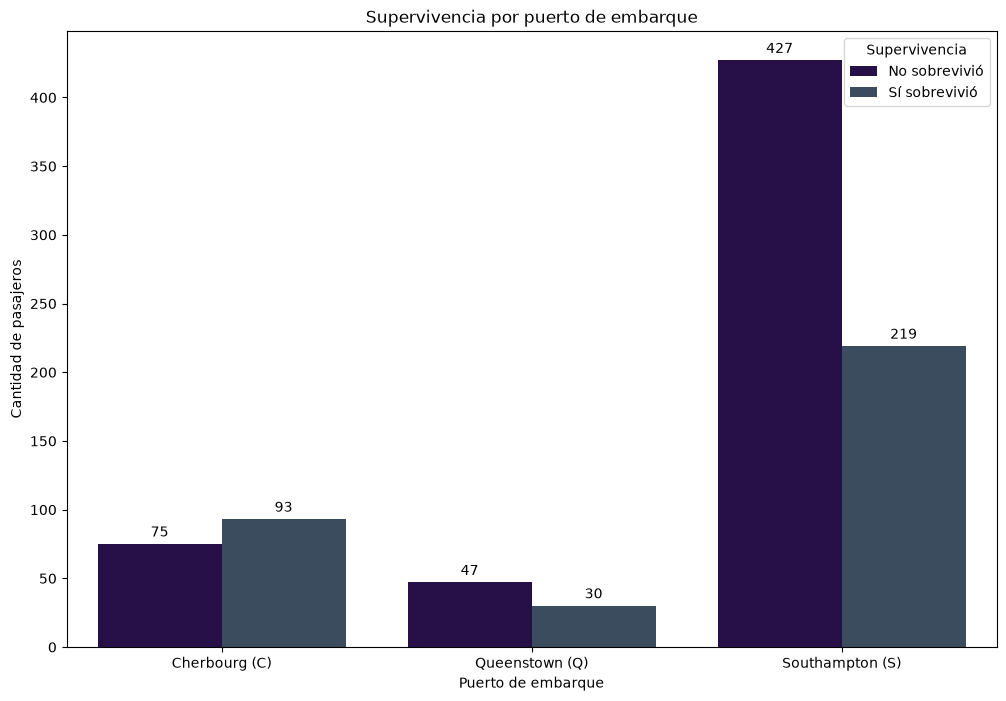

In [12]:
plt.figure(figsize=(12, 8))

# Colores para cada estado de supervivencia
color = ['#240750', '#344C64']

ax = sns.countplot(
    data=df,
    x='Embarked',
    hue='Survived',
    order=['C', 'Q', 'S'],
    palette=color
)

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title('Supervivencia por puerto de embarque')
plt.xlabel('Puerto de embarque')
plt.ylabel('Cantidad de pasajeros')
plt.xticks([0, 1, 2], ['Cherbourg (C)', 'Queenstown (Q)', 'Southampton (S)'])
plt.legend(title='Supervivencia', labels=['No sobrevivió', 'Sí sobrevivió'])
plt.show()

### `Age`

Visualizamos la distribución de las edades y señalamos sus principales medidas de tendencia central.

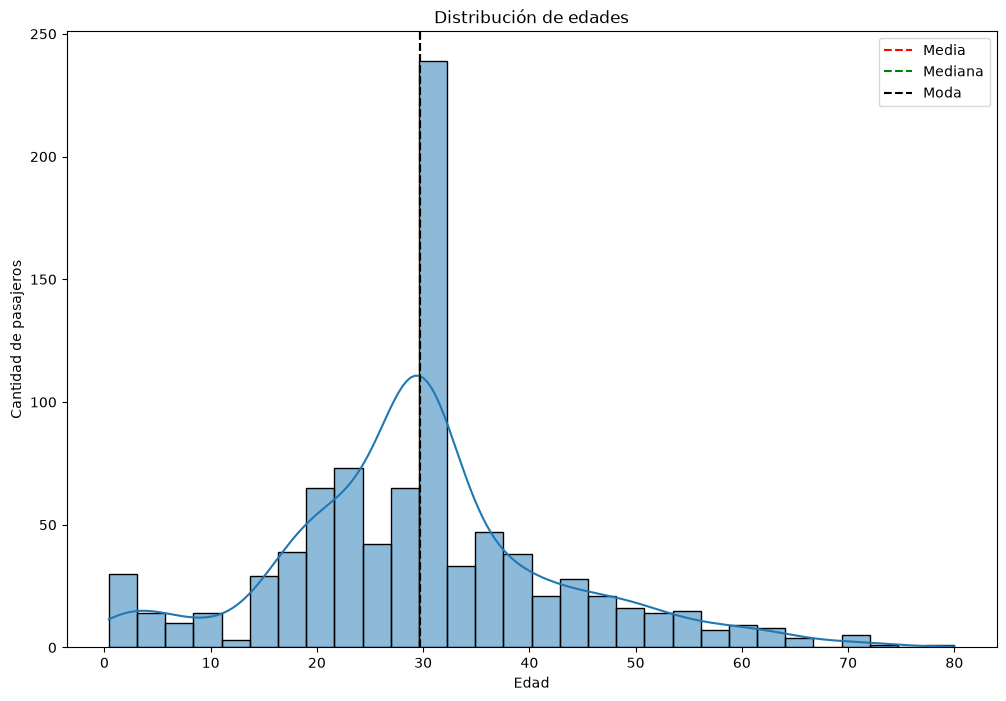

Media: 29.70
Mediana: 29.70
Moda: 29.70


In [13]:
plt.figure(figsize=(12, 8))

sns.histplot(data=df, x='Age', kde=True)
plt.title('Distribución de edades')
plt.xlabel('Edad')
plt.ylabel('Cantidad de pasajeros')
plt.axvline(df['Age'].mean(), color='red', linestyle='--', label='Media')
plt.axvline(df['Age'].median(), color='green', linestyle='--', label='Mediana')
plt.axvline(df['Age'].mode()[0], color='black', linestyle='--', label='Moda')
plt.legend()
plt.show()

# Imprimir los resultados
print(f"Media: {df['Age'].mean():.2f}")
print(f"Mediana: {df['Age'].median():.2f}")
print(f"Moda: {df['Age'].mode()[0]:.2f}")

# Ejercicios

Cada celda siguiente responde de manera independiente a uno de los ejercicios propuestos.

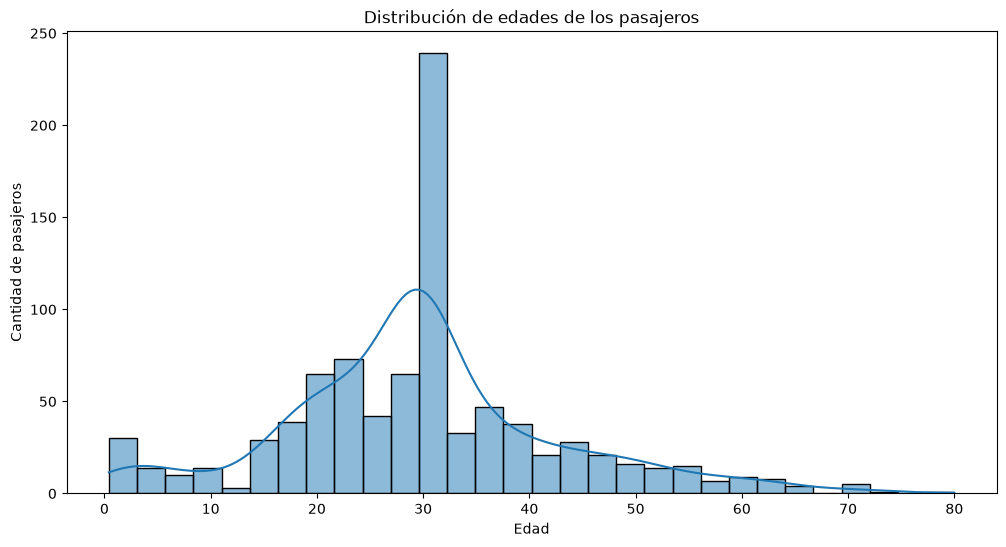

In [14]:
# 1. Distribución de edades
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='Age', bins=30, kde=True)
plt.title('Distribución de edades de los pasajeros')
plt.xlabel('Edad')
plt.ylabel('Cantidad de pasajeros')
plt.show()

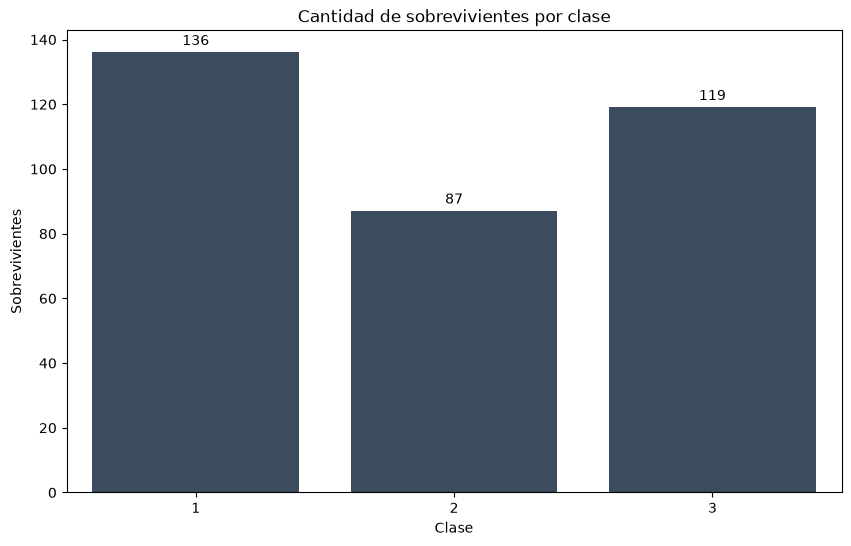

In [15]:
# 2. Cantidad de sobrevivientes por clase
sobrevivientes = df[df['Survived'] == 1]
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=sobrevivientes, x='Pclass', order=[1, 2, 3], color='#344C64')
ax.bar_label(ax.containers[0], padding=3)
plt.title('Cantidad de sobrevivientes por clase')
plt.xlabel('Clase')
plt.ylabel('Sobrevivientes')
plt.show()

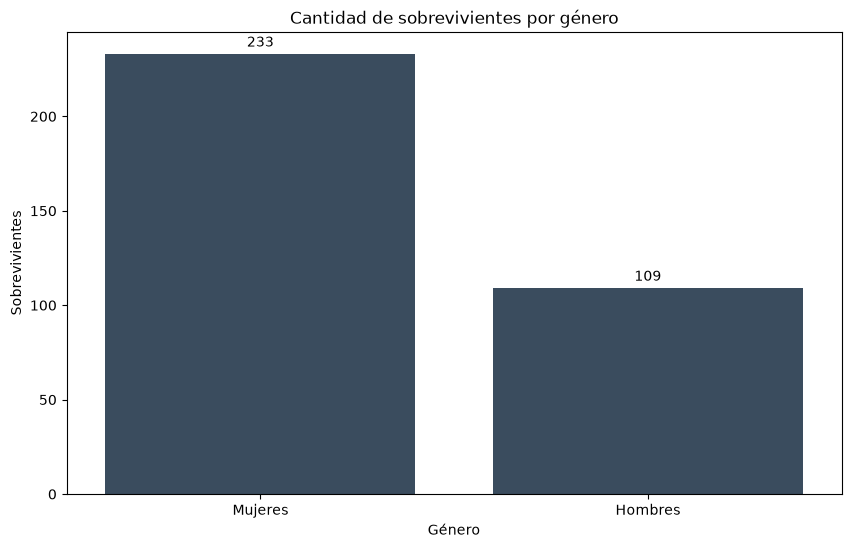

In [16]:
# 3. Cantidad de sobrevivientes por género
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=sobrevivientes, x='Sex', order=['female', 'male'], color='#344C64')
ax.bar_label(ax.containers[0], padding=3)
plt.title('Cantidad de sobrevivientes por género')
plt.xlabel('Género')
plt.ylabel('Sobrevivientes')
plt.xticks([0, 1], ['Mujeres', 'Hombres'])
plt.show()

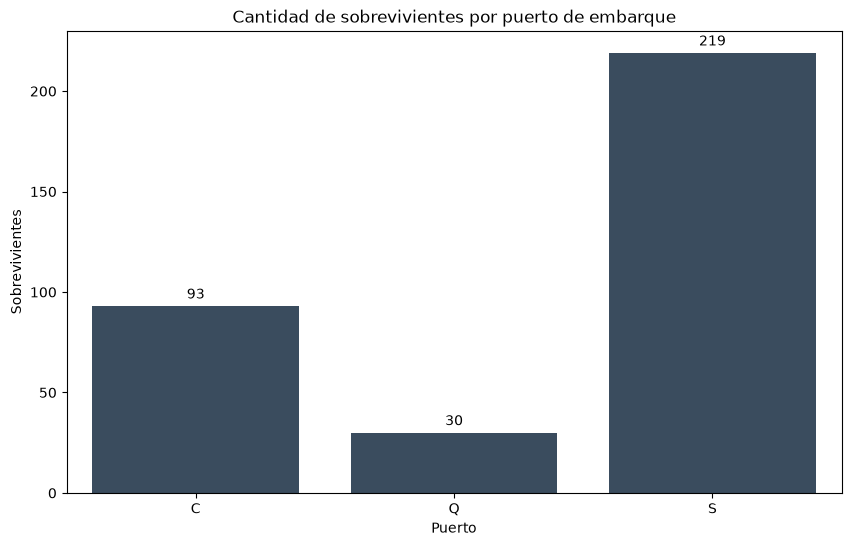

In [17]:
# 4. Cantidad de sobrevivientes por puerto de embarque
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=sobrevivientes, x='Embarked', order=['C', 'Q', 'S'], color='#344C64')
ax.bar_label(ax.containers[0], padding=3)
plt.title('Cantidad de sobrevivientes por puerto de embarque')
plt.xlabel('Puerto')
plt.ylabel('Sobrevivientes')
plt.show()

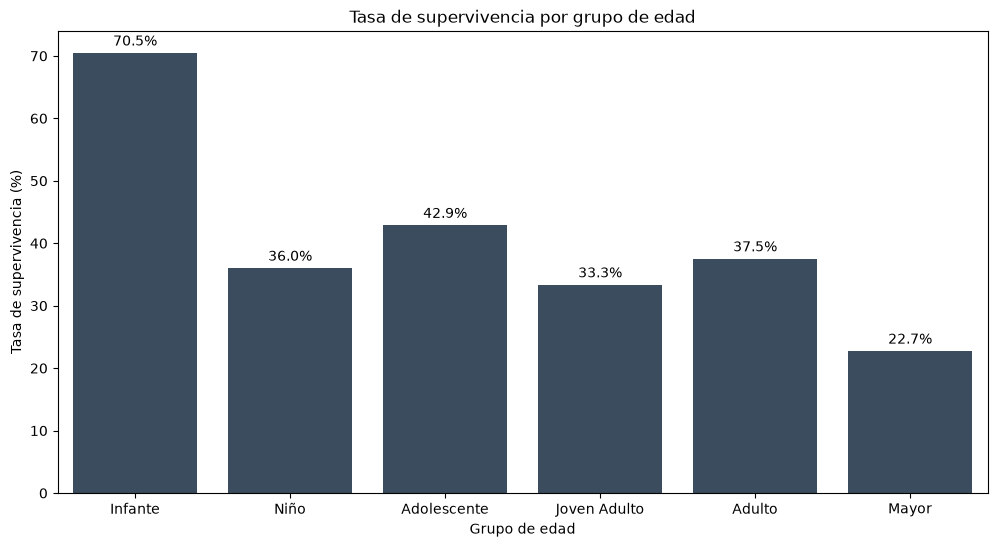

In [18]:
# 5. Tasa de supervivencia por grupo de edad
bins_edad = [0, 5, 12, 18, 25, 60, float('inf')]
etiquetas_edad = ['Infante', 'Niño', 'Adolescente', 'Joven Adulto', 'Adulto', 'Mayor']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins_edad, labels=etiquetas_edad, include_lowest=True)
tasa_por_edad = (df.groupby('AgeGroup', observed=False)['Survived'].mean() * 100).reset_index()
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=tasa_por_edad, x='AgeGroup', y='Survived', color='#344C64')
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3)
plt.title('Tasa de supervivencia por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Tasa de supervivencia (%)')
plt.show()

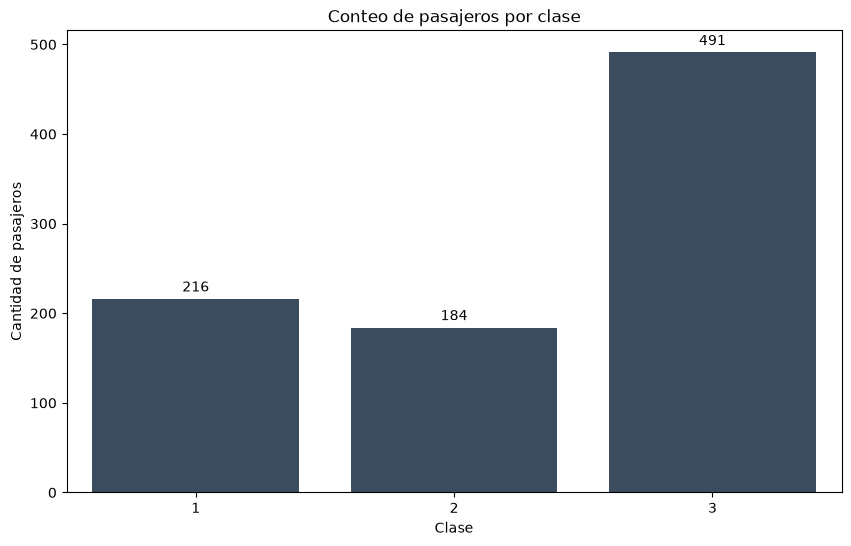

In [19]:
# 6. Conteo de pasajeros por clase
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='Pclass', order=[1, 2, 3], color='#344C64')
ax.bar_label(ax.containers[0], padding=3)
plt.title('Conteo de pasajeros por clase')
plt.xlabel('Clase')
plt.ylabel('Cantidad de pasajeros')
plt.show()

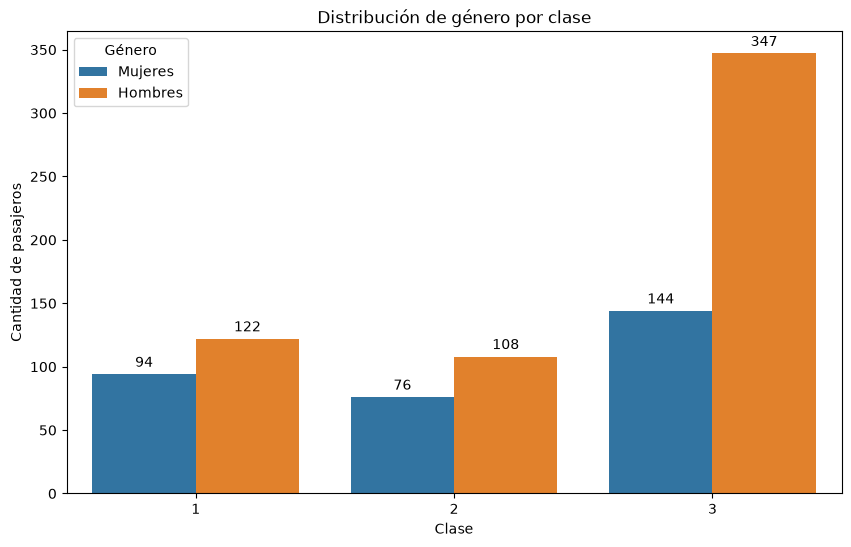

In [20]:
# 7. Distribución de género dentro de cada clase
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='Pclass', hue='Sex', order=[1, 2, 3])
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.title('Distribución de género por clase')
plt.xlabel('Clase')
plt.ylabel('Cantidad de pasajeros')
plt.legend(title='Género', labels=['Mujeres', 'Hombres'])
plt.show()

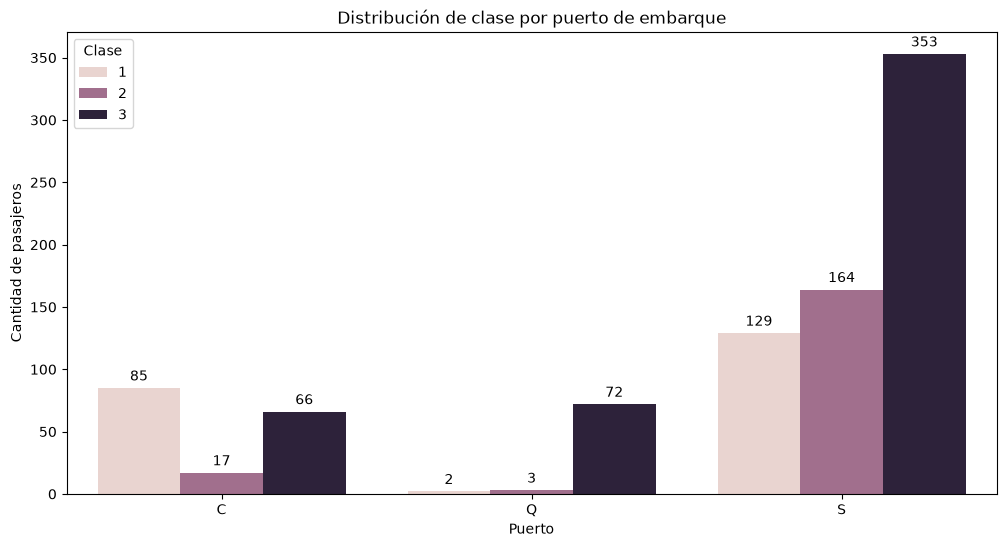

In [21]:
# 8. Distribución de clase por puerto de embarque
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df, x='Embarked', hue='Pclass', order=['C', 'Q', 'S'])
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.title('Distribución de clase por puerto de embarque')
plt.xlabel('Puerto')
plt.ylabel('Cantidad de pasajeros')
plt.legend(title='Clase')
plt.show()

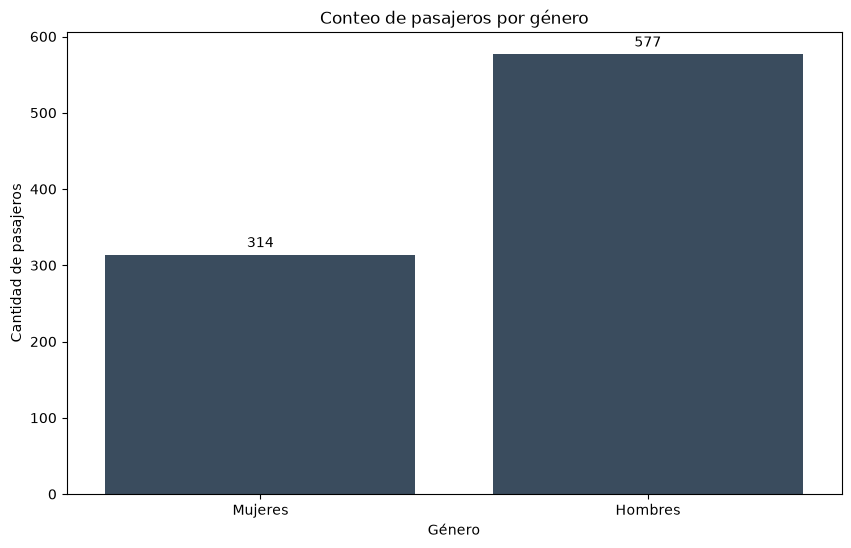

In [22]:
# 9. Conteo de pasajeros por género
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='Sex', order=['female', 'male'], color='#344C64')
ax.bar_label(ax.containers[0], padding=3)
plt.title('Conteo de pasajeros por género')
plt.xlabel('Género')
plt.ylabel('Cantidad de pasajeros')
plt.xticks([0, 1], ['Mujeres', 'Hombres'])
plt.show()

In [23]:
# 10. Edad mínima y máxima
print(f"Edad mínima: {df['Age'].min():.2f} años")
print(f"Edad máxima: {df['Age'].max():.2f} años")

Edad mínima: 0.42 años
Edad máxima: 80.00 años


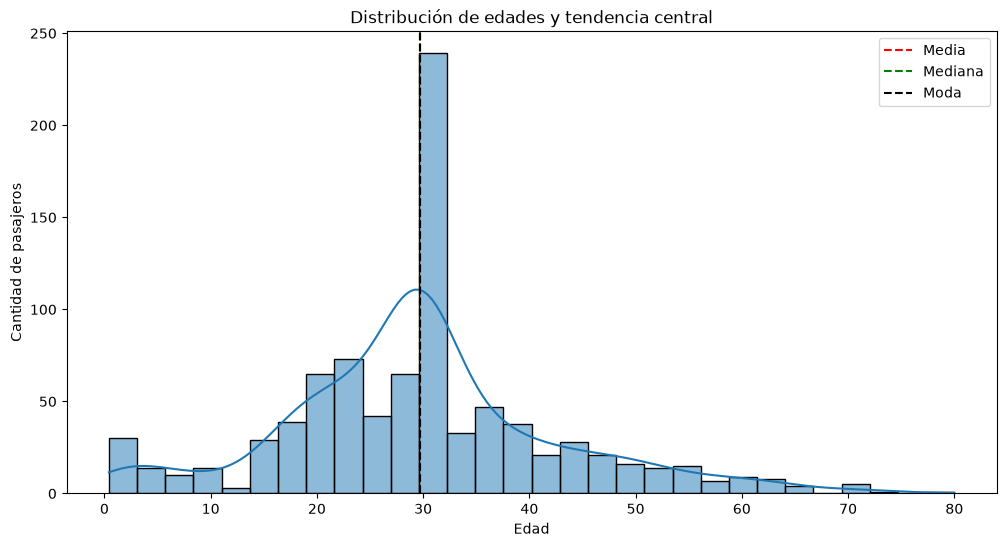

In [24]:
# 11. Distribución de edades con media, mediana y moda
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='Age', bins=30, kde=True)
plt.axvline(df['Age'].mean(), color='red', linestyle='--', label='Media')
plt.axvline(df['Age'].median(), color='green', linestyle='--', label='Mediana')
plt.axvline(df['Age'].mode()[0], color='black', linestyle='--', label='Moda')
plt.title('Distribución de edades y tendencia central')
plt.xlabel('Edad')
plt.ylabel('Cantidad de pasajeros')
plt.legend()
plt.show()

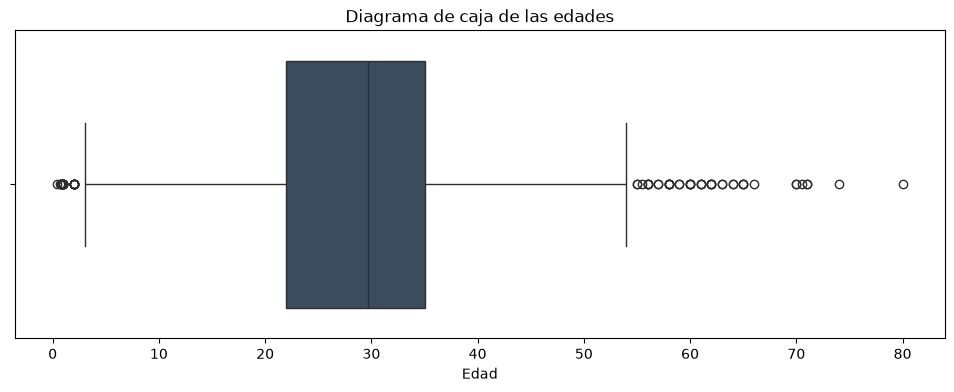

In [25]:
# 12. Boxplot de edad
plt.figure(figsize=(12, 4))
sns.boxplot(data=df, x='Age', color='#344C64')
plt.title('Diagrama de caja de las edades')
plt.xlabel('Edad')
plt.show()

In [26]:
# 13. Tarifa mínima y máxima
print(f"Tarifa mínima: {df['Fare'].min():.2f}")
print(f"Tarifa máxima: {df['Fare'].max():.2f}")

Tarifa mínima: 0.00
Tarifa máxima: 512.33


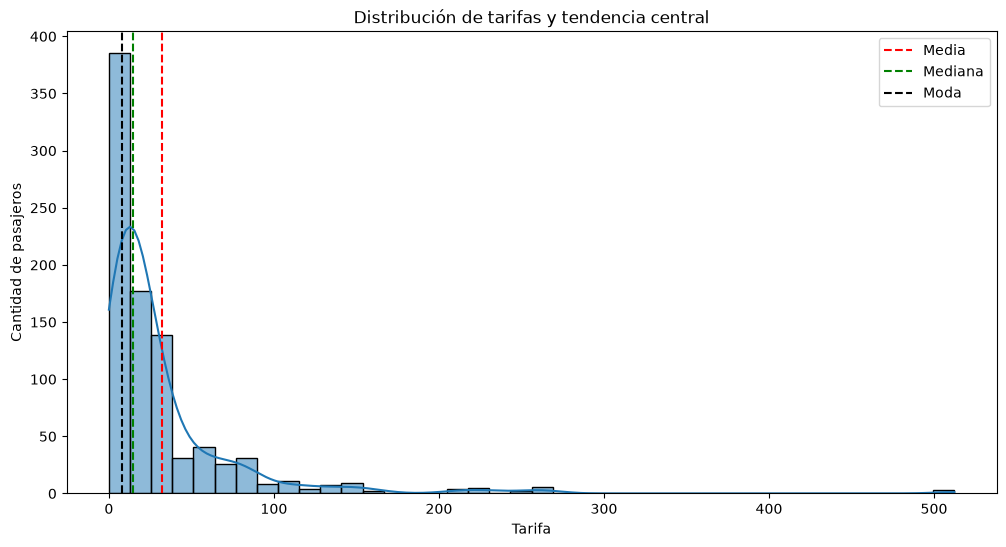

In [27]:
# 14. Distribución de tarifas con media, mediana y moda
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='Fare', bins=40, kde=True)
plt.axvline(df['Fare'].mean(), color='red', linestyle='--', label='Media')
plt.axvline(df['Fare'].median(), color='green', linestyle='--', label='Mediana')
plt.axvline(df['Fare'].mode()[0], color='black', linestyle='--', label='Moda')
plt.title('Distribución de tarifas y tendencia central')
plt.xlabel('Tarifa')
plt.ylabel('Cantidad de pasajeros')
plt.legend()
plt.show()

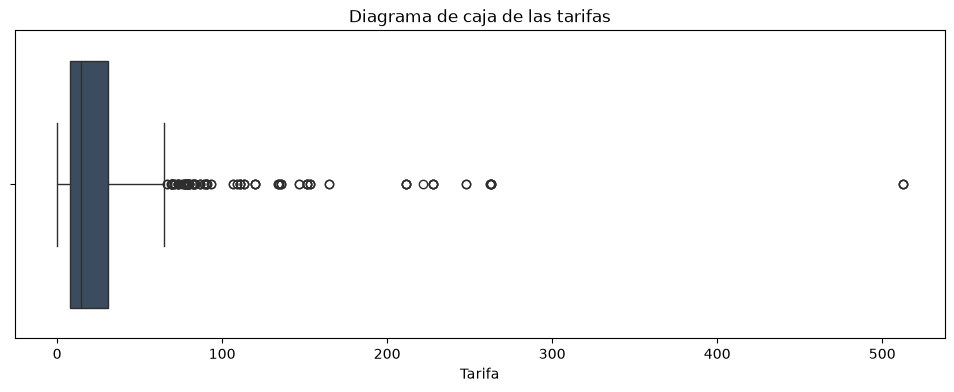

In [28]:
# 15. Boxplot de tarifa
plt.figure(figsize=(12, 4))
sns.boxplot(data=df, x='Fare', color='#344C64')
plt.title('Diagrama de caja de las tarifas')
plt.xlabel('Tarifa')
plt.show()

In [29]:
# 16. Pasajeros que pagaron una tarifa de cero
pasajeros_tarifa_cero = df[df['Fare'] == 0]
print(f"Total de pasajeros con tarifa cero: {len(pasajeros_tarifa_cero)}")
pasajeros_tarifa_cero

Total de pasajeros con tarifa cero: 15


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,AgeGroup
179,0,3,male,36.000000,0,0,0.0,S,Adulto
263,0,1,male,40.000000,0,0,0.0,S,Adulto
271,1,3,male,25.000000,0,0,0.0,S,Joven Adulto
277,0,2,male,29.699118,0,0,0.0,S,Adulto
302,0,3,male,19.000000,0,0,0.0,S,Joven Adulto
413,0,2,male,29.699118,0,0,0.0,S,Adulto
466,0,2,male,29.699118,0,0,0.0,S,Adulto
481,0,2,male,29.699118,0,0,0.0,S,Adulto
597,0,3,male,49.000000,0,0,0.0,S,Adulto
633,0,1,male,29.699118,0,0,0.0,S,Adulto


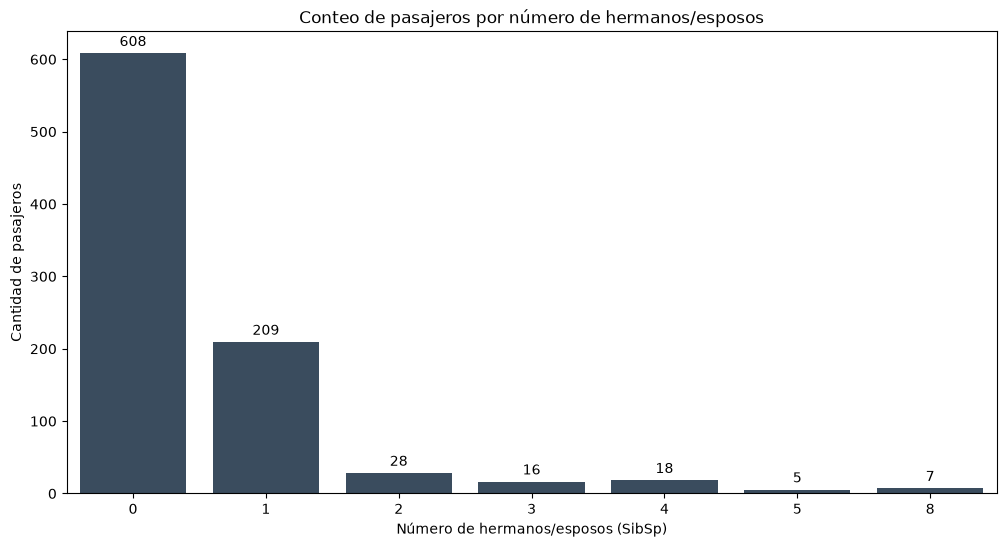

In [30]:
# 17. Conteo de pasajeros por SibSp
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df, x='SibSp', color='#344C64')
ax.bar_label(ax.containers[0], padding=3)
plt.title('Conteo de pasajeros por número de hermanos/esposos')
plt.xlabel('Número de hermanos/esposos (SibSp)')
plt.ylabel('Cantidad de pasajeros')
plt.show()

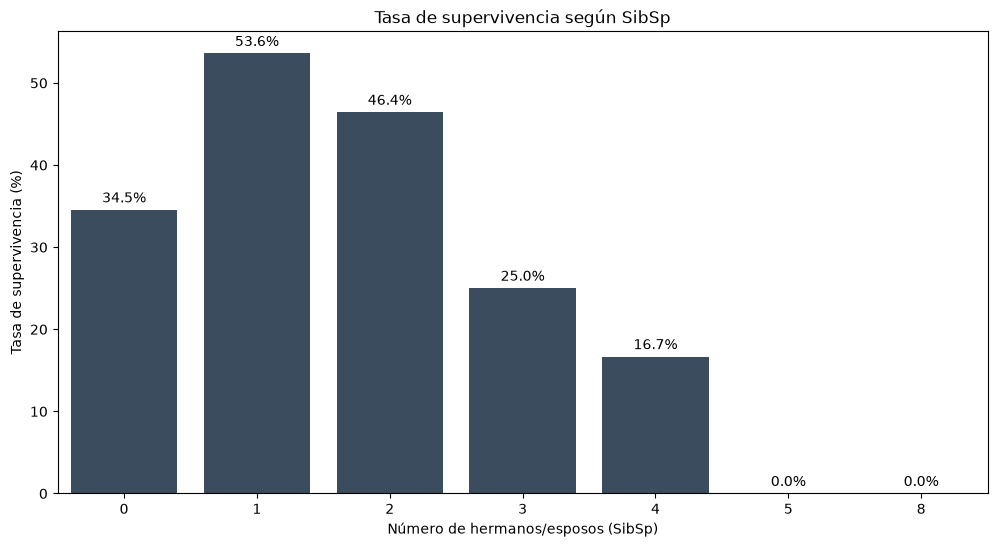

In [31]:
# 18. Tasa de supervivencia por SibSp
tasa_por_sibsp = (df.groupby('SibSp')['Survived'].mean() * 100).reset_index()
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=tasa_por_sibsp, x='SibSp', y='Survived', color='#344C64')
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3)
plt.title('Tasa de supervivencia según SibSp')
plt.xlabel('Número de hermanos/esposos (SibSp)')
plt.ylabel('Tasa de supervivencia (%)')
plt.show()

In [32]:
# 19. Porcentaje de supervivencia para cada valor de SibSp
porcentaje_sibsp = (df.groupby('SibSp')['Survived'].mean() * 100).round(2)
porcentaje_sibsp.rename('Porcentaje de supervivencia (%)')

SibSp
0    34.54
1    53.59
2    46.43
3    25.00
4    16.67
5     0.00
8     0.00
Name: Porcentaje de supervivencia (%), dtype: float64

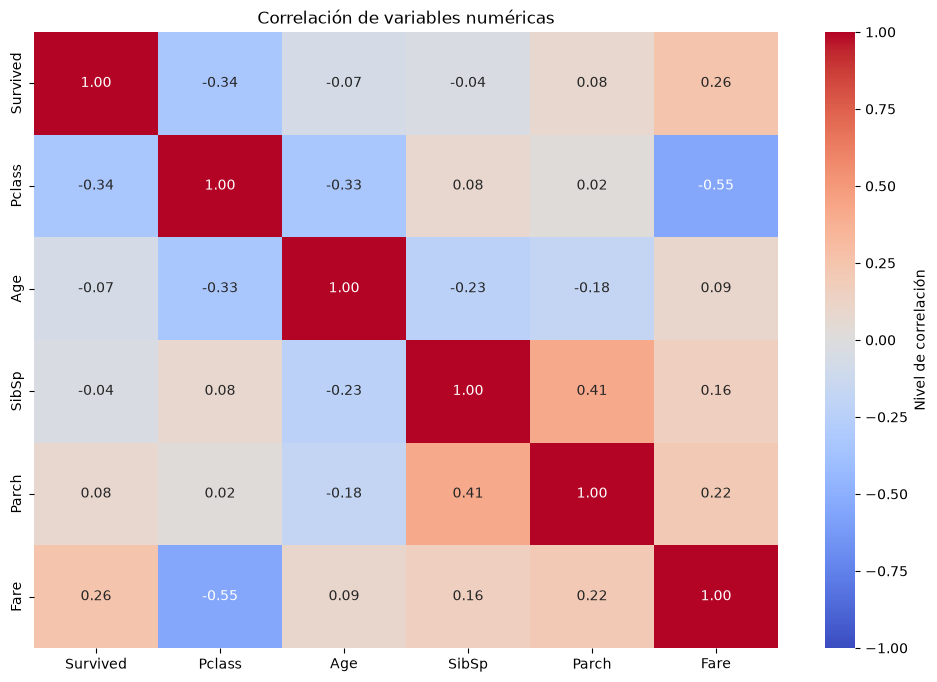

In [33]:
# 20. Matriz de correlación de las características numéricas
columnas_numericas = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
matriz_correlacion = df[columnas_numericas].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(
    matriz_correlacion,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    cbar_kws={'label': 'Nivel de correlación'}
)
plt.title('Correlación de variables numéricas')
plt.show()